# Buổi 2

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [26]:
print(df.info())
print("\nn mẫu:")
print(df["species"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

n mẫu:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Tập dữ liệu có 150 mẫu vs 4 đặc trưng và 1 cột species. Mỗi loại hoa đều có 50 mẫu.

In [27]:
num_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

summary = pd.DataFrame(index=num_cols)
summary["mean"] = df[num_cols].mean()
summary["median"] = df[num_cols].median()
summary["mode"] = df[num_cols].mode().iloc[0]
summary["var"] = df[num_cols].var()
summary["std"] = df[num_cols].std()
summary["min"] = df[num_cols].min()
summary["Q1"] = df[num_cols].quantile(0.25)
summary["Q3"] = df[num_cols].quantile(0.75)
summary["max"] = df[num_cols].max()
summary["IQR"] = summary["Q3"] - summary["Q1"]

summary

,mean,median,mode,var,std,min,Q1,Q3,max,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,5.1,6.4,7.9,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,2.8,3.3,4.4,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,1.6,5.1,6.9,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,0.3,1.8,2.5,1.5


- petal_length và petal_width có std và IQR lớn.
- sepal_width có std nhỏ nhất, các giá trị tập trung gần mean.
- mean và median của các biến khá gần nhau nên phân phối tương đối đối xứng.

In [28]:
print("mean từng loài:")
display(df.groupby("species")[num_cols].mean())

print("std từng loài:")
display(df.groupby("species")[num_cols].std())

mean từng loài:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


std từng loài:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650



- Loại setosa có kích thước cánh hoa nhỏ hơn hẳn so với hai loại còn lại
- Versicolor và virginica có sự chồng lấp nhiều hơn ở chiều dài và chiều rộng đài hoa

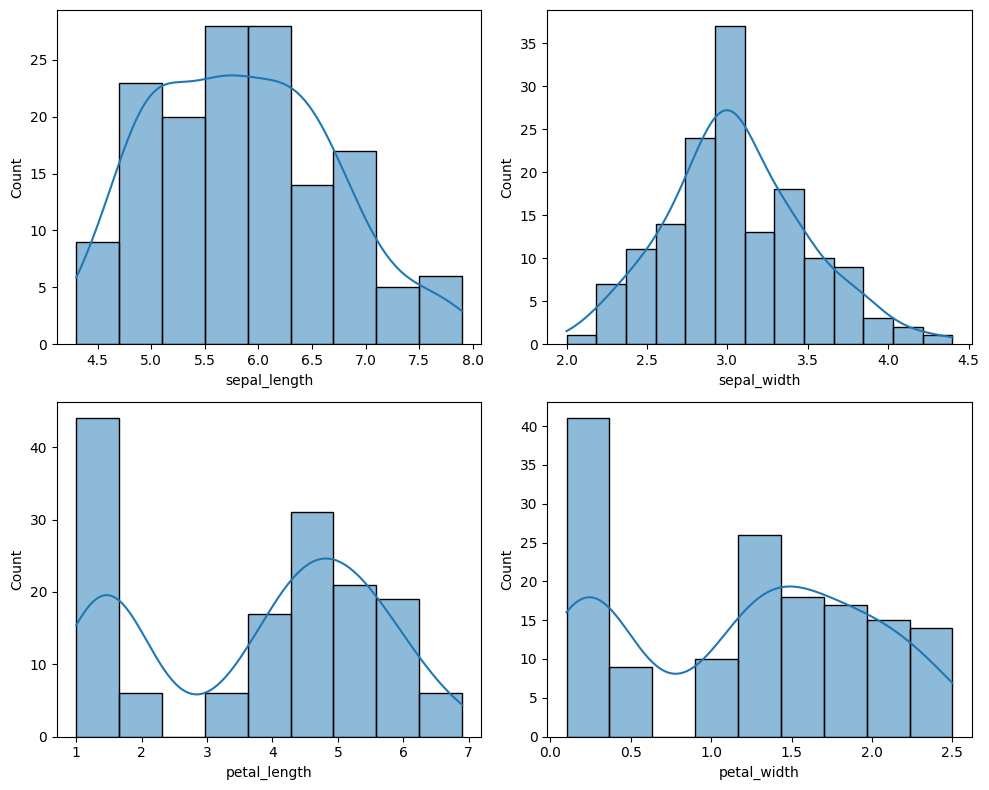

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df["sepal_length"], kde=True, ax=axes[0, 0])
sns.histplot(df["sepal_width"], kde=True, ax=axes[0, 1])
sns.histplot(df["petal_length"], kde=True, ax=axes[1, 0])
sns.histplot(df["petal_width"], kde=True, ax=axes[1, 1])

plt.tight_layout()
plt.show()

- sepal_length và sepal_width có dạng hình chuông tương tự phân phối chuẩn
- petal_length và petal_width có 2 đỉnh do nhóm setosa khác hẳn với hai nhóm còn lại

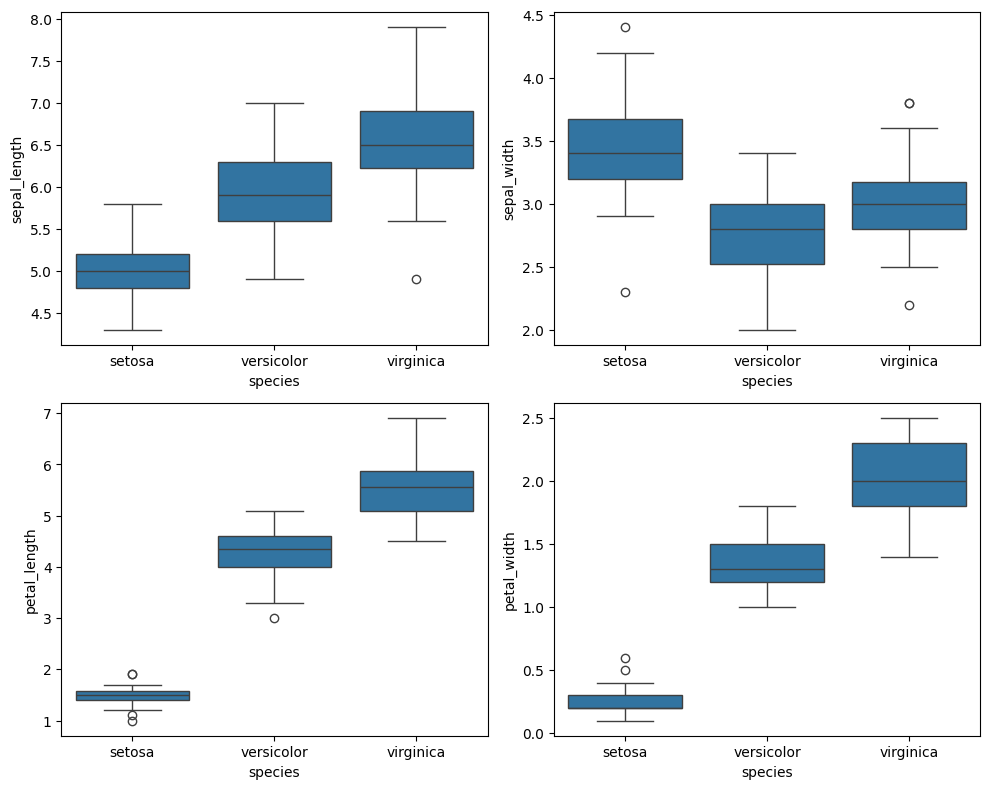

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(x="species", y="sepal_length", data=df, ax=axes[0, 0])
sns.boxplot(x="species", y="sepal_width", data=df, ax=axes[0, 1])
sns.boxplot(x="species", y="petal_length", data=df, ax=axes[1, 0])
sns.boxplot(x="species", y="petal_width", data=df, ax=axes[1, 1])

plt.tight_layout()
plt.show()

- Setosa dễ dàng phân biệt nhờ cánh hoa nhỏ hơn nhiều
- Cột sepal_width của setosa có một vài outlier 

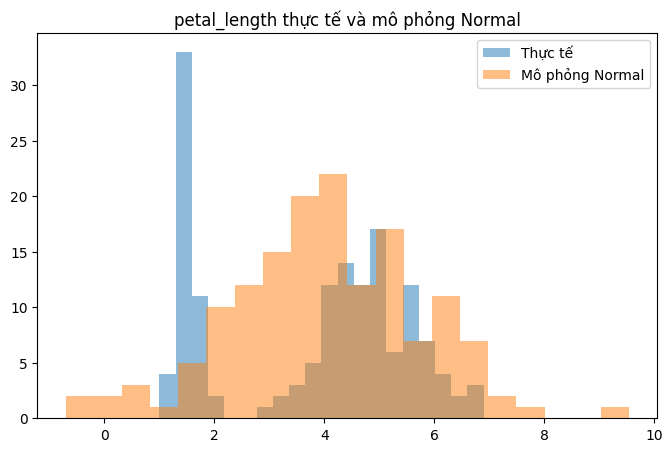

In [31]:
mean_val = df["petal_length"].mean()
std_val = df["petal_length"].std()

simulated = np.random.normal(mean_val, std_val, 150)

plt.figure(figsize=(8, 5))
plt.hist(df["petal_length"], bins=20, alpha=0.5, label="Thực tế")
plt.hist(simulated, bins=20, alpha=0.5, label="Mô phỏng Normal")
plt.legend()
plt.title("petal_length thực tế và mô phỏng Normal")
plt.show()

Dữ liệu thực tế của petal_length có 2 đỉnh trong khi dữ liệu mô phỏng Normal chỉ có 1 đỉnh => phân phối Normal không phù hợp cho toàn bộ biến petal_length

In [32]:
print("covariance matrix:")
display(df[num_cols].cov())

print("correlation matrix:")
display(df[num_cols].corr())

covariance matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


correlation matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


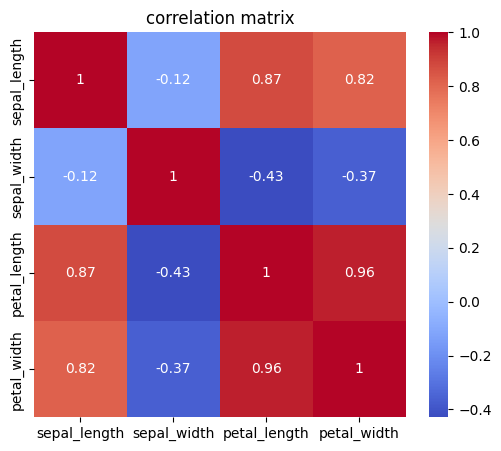

In [33]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

-petal_length và petal_width có tương quan vs nhau lớn (r gần = 0.96)
-sepal_width có tương quan khá yếu với các đặc trưng còn lại

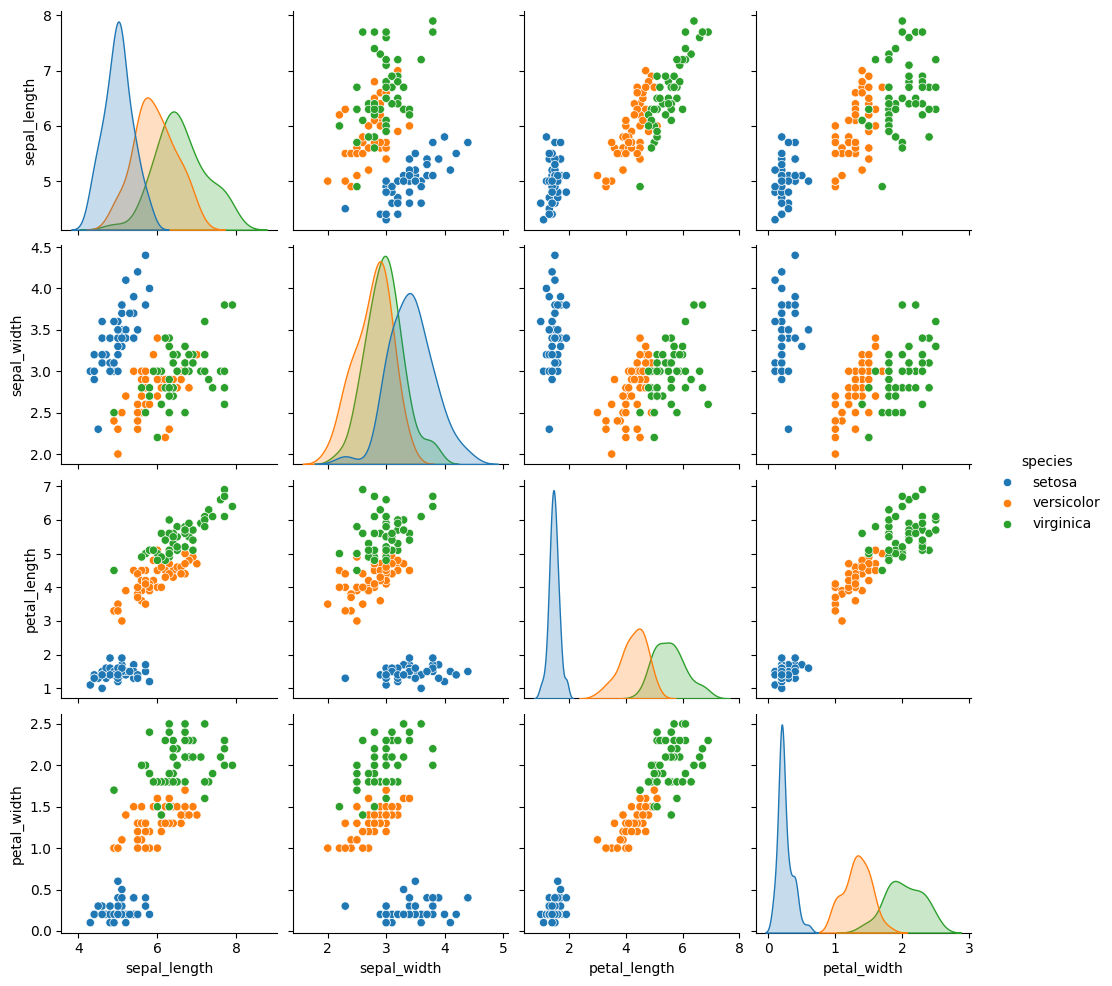

In [34]:
sns.pairplot(df, hue="species")
plt.show()

- Nhóm setosa hoàn toàn tách biệt trên các biểu đồ phân tán của cánh hoa 
- petal_length và petal_width giúp phân loại tốt nhất giữa các loài hoa do có sự khác nhau lớn 

In [35]:
b = 0.01
positive_given_b = 0.99
positive_given_not_b = 0.05

positive = positive_given_b * b + positive_given_not_b * (1 - b)
b_given_positive = (positive_given_b * b) / positive

print("P(+):", positive)
print("P(B | +):", b_given_positive)

P(+): 0.0594
P(B | +): 0.16666666666666669


Dù kết quả xét nghiệm là dương tính thì xs thật sự mắc bệnh cx chỉ khoảng 16.7% do tỉ lệ mắc bệnh trong cộng đồng quá thấp chỉ có 1% thui

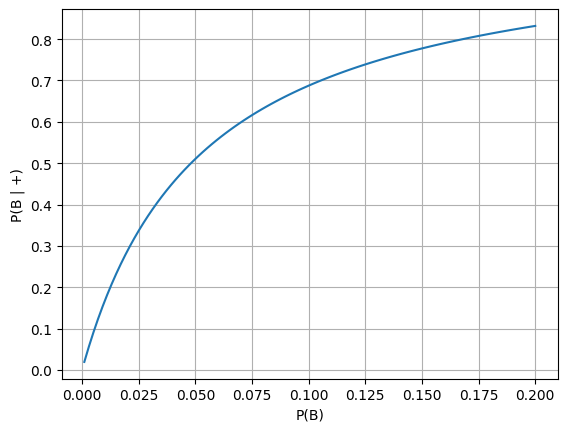

In [36]:
b_list = np.linspace(0.001, 0.2, 100)
b_given_positive_list = []

for p in b_list:
    positive = 0.99 * p + 0.05 * (1 - p)
    b_given_positive = (0.99 * p) / positive
    b_given_positive_list.append(b_given_positive)

plt.plot(b_list, b_given_positive_list)
plt.xlabel("P(B)")
plt.ylabel("P(B | +)")
plt.grid(True)
plt.show()

 Khi P(B) tăng lên thì xác suất hậu nghiệm P(B | +) cũng tăng nhanh. Khi P(B) còn nhỏ thì phần lớn các trường hợp dương tính là false positive hết